# Predict using some model and time series data as input 

- Recipe 2-1. Moving Average (MA) Forecast 
- Recipe 2-2. Autoregressive (AR) Model 
- Recipe 2-3. Autoregressive Moving Average (ARMA) Model 
- Recipe 2-4. Autoregressive Integrated Moving Average (ARIMA) Model 
- Recipe 2-5. Grid search Hyperparameter Tuning for Autoregressive Integrated Moving Average (ARIMA) Model
- Recipe 2-6. Seasonal Autoregressive Integrated Moving Average (SARIMA) Model 
- Recipe 2-7. Simple Exponential Smoothing (SES) Model 
- Recipe 2-8. Holt-Winters (HW) Model

In [62]:
from pandas import read_csv, Grouper, DataFrame, concat
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from sklearn.metrics import mean_squared_error
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf
import warnings

## 2.1 Moving average (MA) forecast

### Understand

MA: thể hiện sự thay đổi trung bình của dữ liệu theo thời gian. Nhằm làm mượt dữ liệu, loại bỏ nhiễu.
- Sử dụng kỹ thuật cửa sổ trượt giả sử window_length=5, 
- Tính giá trị trung bình trong window đó, trượt đến cuối.

### Implement

#### Load the data

In [63]:
# read US GDP data
us_gdp_data = pd.read_csv('../data/GDPUS.csv', header=0)

In [64]:
date_rng = pd.date_range(start='1/1/1929', end='31/12/1991', freq='A')
print(date_rng)

us_gdp_data['TimeIndex'] = pd.DataFrame(date_rng, columns=['Year'])

DatetimeIndex(['1929-12-31', '1930-12-31', '1931-12-31', '1932-12-31',
               '1933-12-31', '1934-12-31', '1935-12-31', '1936-12-31',
               '1937-12-31', '1938-12-31', '1939-12-31', '1940-12-31',
               '1941-12-31', '1942-12-31', '1943-12-31', '1944-12-31',
               '1945-12-31', '1946-12-31', '1947-12-31', '1948-12-31',
               '1949-12-31', '1950-12-31', '1951-12-31', '1952-12-31',
               '1953-12-31', '1954-12-31', '1955-12-31', '1956-12-31',
               '1957-12-31', '1958-12-31', '1959-12-31', '1960-12-31',
               '1961-12-31', '1962-12-31', '1963-12-31', '1964-12-31',
               '1965-12-31', '1966-12-31', '1967-12-31', '1968-12-31',
               '1969-12-31', '1970-12-31', '1971-12-31', '1972-12-31',
               '1973-12-31', '1974-12-31', '1975-12-31', '1976-12-31',
               '1977-12-31', '1978-12-31', '1979-12-31', '1980-12-31',
               '1981-12-31', '1982-12-31', '1983-12-31', '1984-12-31',
      

/tmp/ipykernel_1178399/3909651314.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  date_rng = pd.date_range(start='1/1/1929', end='31/12/1991', freq='A')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


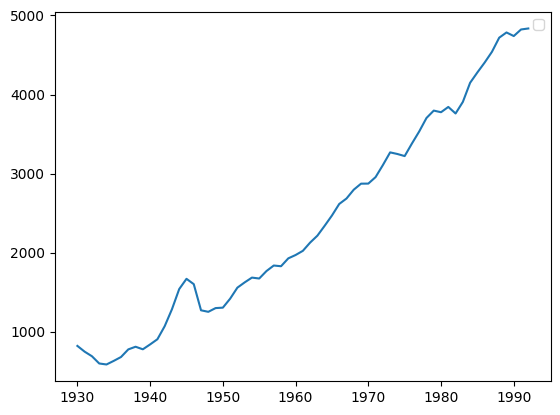

In [65]:
plt.plot(us_gdp_data.TimeIndex, us_gdp_data.GDP)
plt.legend(loc='best')
plt.show()

#### Using rolling mean to get the MA

In [66]:
def predict_using_ma(data, rolling=5):
    mvg_avg_us_gdp = data.copy()
    #calculating the rolling mean - with window 5
    mvg_avg_us_gdp['moving_avg_forecast'] = data['GDP'].rolling(rolling).mean()
   
    plt.plot(data['GDP'], label='US GDP')
    plt.plot(mvg_avg_us_gdp['moving_avg_forecast'], label=F'US GDP MA({rolling})')
    plt.legend(loc='best')
    plt.show()

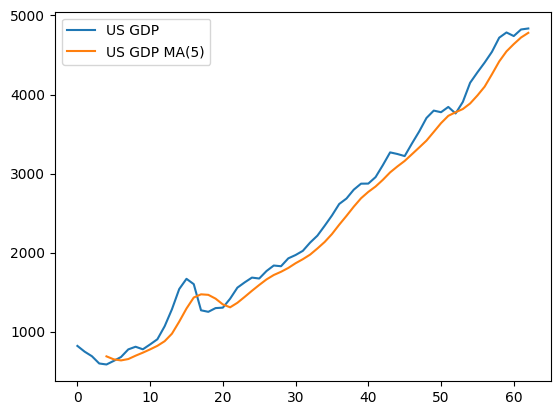

In [67]:
MA_ROLLING = 5
predict_using_ma(data=us_gdp_data, rolling=MA_ROLLING)

## 2.2 Autoregressive (AR) model

### Understand

AR: giả định rằng các giá trị tương lai sẽ bị ảnh hưởng bởi các giá trị trong quá khứ (lagged values) và giá trị dự báo sẽ là tổ hợp tuyến tính của các lagged values này.
- Bắt buộc input phải là dữ liệu dừng (stationary), tính chất thống kê không thay đổi theo thời gian, nghĩa là:
    + **Mean không đổi**: e.g. nhiệt độ trong phòng giao động nhẹ  ~24.7 - ~25.3, nhưng mean của nó quanh 25 độ
    + **Variance không đổi**: giao động điều đặn trong một biên độ chứ không tăng giảm hay đứng yên bất thường
    + **Covariance không đổi**: e.g. sự liên quan giữa giá ngày hôm nay và ngày mai phải giống với sự liên quan giữa giá ngày hôm kia và hôm trước đó.

### Implement

### Load the data and check stationary

<Axes: >

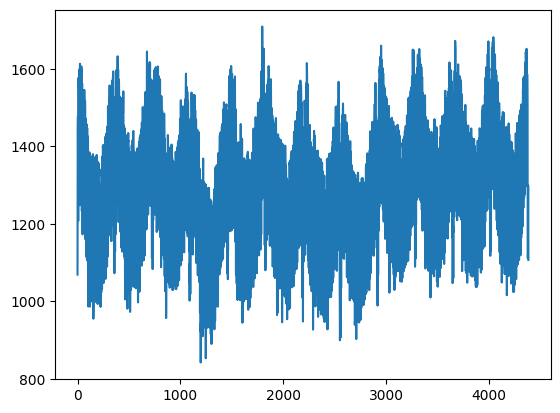

In [68]:
data = pd.read_csv('../data/opsd_germany_daily.csv',sep=",")
data['Consumption'].plot()

In [69]:
data_stationarity_test = adfuller(data['Consumption'], 
autolag='AIC')
print("P-value: ", data_stationarity_test[1])

P-value:  4.7440549018425884e-08


- P-value = 4.744e-08 (tức là 0.00000004744) < 0.05

&rarr; Stationary

/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


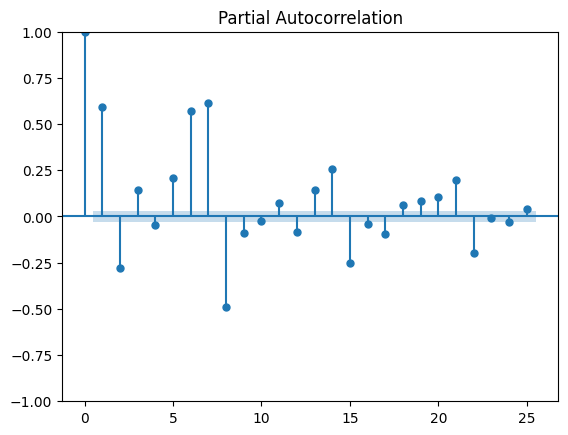

In [70]:
pacf_plot = plot_pacf(data['Consumption'], lags=25)

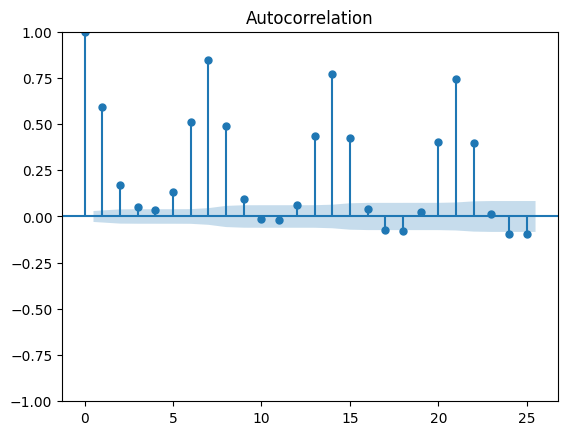

In [71]:
acf_plot = plot_acf(data['Consumption'], lags=25)

### Create data and training

In [72]:
AR_P = 8

In [73]:
train_df = data['Consumption'][:len(data)-100]
test_df = data['Consumption'][len(data)-100:]

In [74]:
model_ar = AutoReg(train_df, lags=AR_P).fit()

print(model_ar.summary())

                            AutoReg Model Results                             
Dep. Variable:            Consumption   No. Observations:                 4283
Model:                     AutoReg(8)   Log Likelihood              -24231.812
Method:               Conditional MLE   S.D. of innovations             70.058
Date:                Tue, 07 Apr 2026   AIC                          48483.625
Time:                        23:59:07   BIC                          48547.230
Sample:                             8   HQIC                         48506.095
                                 4283                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            121.2792     14.444      8.397      0.000      92.969     149.589
Consumption.L1     0.6393      0.013     47.751      0.000       0.613       0.666
Consumption.L2    -0.0966      0.011

### Predict

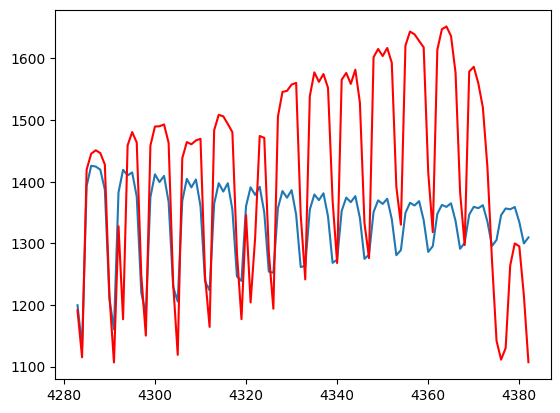

In [75]:
predictions = model_ar.predict(start=len(train_df),
end=(len(data)-1), dynamic=False)
    
matplotlib.pyplot.plot(predictions)
matplotlib.pyplot.plot(test_df, color='red')

In [76]:
rmse_ar = np.sqrt(mean_squared_error(test_df.values, predictions.values))
print("RMSE (AR):", rmse_ar)

RMSE (AR): 152.620871202568


## 2.3 Autoregressive Moving Average (ARMA) model

### Implement

In [77]:
btc_data = pd.read_csv("../data/btc.csv")
# btc_data = pd.read_csv("../btc_6months_1h.csv")
print(btc_data.head())

         Date       BTC-USD
0  2017-12-31  14156.400391
1  2018-01-01  13657.200195
2  2018-01-02  14982.099609
3  2018-01-03  15201.000000
4  2018-01-04  15599.200195


In [78]:
btc_data.index = pd.to_datetime(btc_data['Date'],format='%Y-%m-%d')
del btc_data['Date']

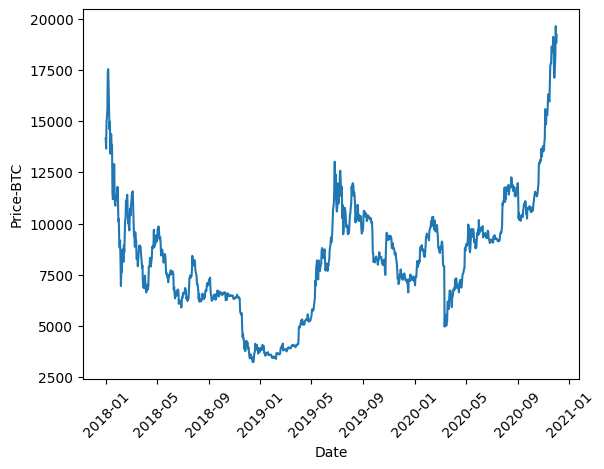

In [79]:
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.plot(btc_data.index, btc_data['BTC-USD'], )

#### Prepare data and training

In [80]:
train_data = btc_data[btc_data.index < pd.to_datetime("2020-11-01", format='%Y-%m-%d')]
test_data = btc_data[btc_data.index > pd.to_datetime("2020-11-01", format='%Y-%m-%d')]
print(train_data.shape)
print(test_data.shape)

(1036, 1)
(31, 1)


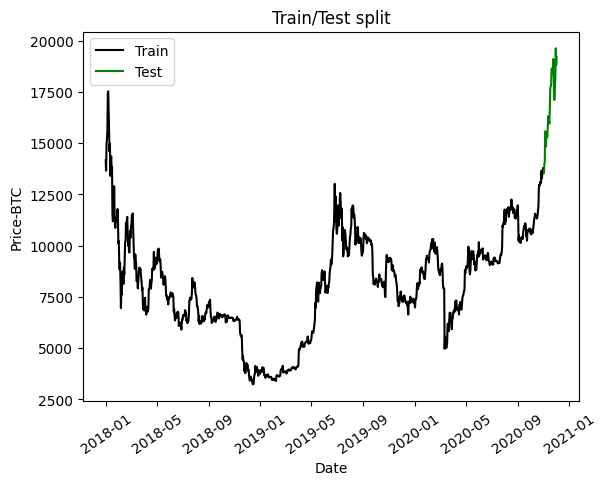

In [81]:
plt.plot(train_data, color = "black", label = 'Train')
plt.plot(test_data, color = "green", label = 'Test')
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=35)
plt.title("Train/Test split")
plt.legend()
plt.show()

In [82]:
actuals = train_data['BTC-USD']

In [83]:
ARMA_model = ARIMA(actuals, order = (1, 0, 1))
ARMA_model = ARMA_model.fit()

/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [84]:
predictions = ARMA_model.get_forecast(len(test_data.index))
predictions_df = predictions.conf_int(alpha = 0.05)
predictions_df["Predictions"] = ARMA_model.predict(start = predictions_df.index[0], end = predictions_df.index[-1])
predictions_df.index = test_data.index
predictions_arma = predictions_df["Predictions"]

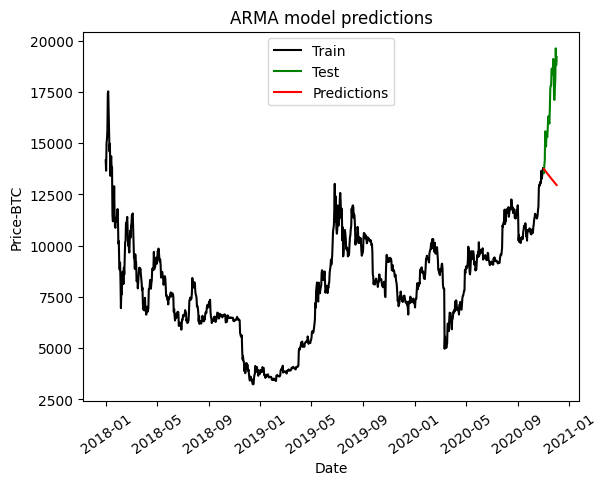

In [85]:
plt.plot(train_data, color = "black", label = 'Train')
plt.plot(test_data, color = "green", label = 'Test')
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=35)
plt.title("ARMA model predictions")
plt.plot(predictions_arma, color="red", label = 'Predictions')
plt.legend()
plt.show()

In [86]:
rmse_arma = np.sqrt(mean_squared_error(test_data["BTC-USD"].values, predictions_df["Predictions"]))
print("RMSE: ",rmse_arma)

RMSE:  4017.1450255192035


- `RMSE=4017`, cho thấy model học chưa tốt

## ARIMA model

### Implement

In [87]:
# differencing
ts_diff = actuals - actuals.shift(periods=4)
ts_diff.dropna(inplace=True)

In [88]:
# checking for stationarity
result = adfuller(ts_diff)
pval = result[1]
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -6.124168
p-value: 0.000000


- Oke

In [98]:
from statsmodels.tsa.stattools import acf as sm_acf, pacf as sm_pacf
lag_acf = sm_acf(ts_diff, nlags=20)
lag_pacf = sm_pacf(ts_diff, nlags=20, method='ols')

#### Plot ACF and PACF to get p and q values

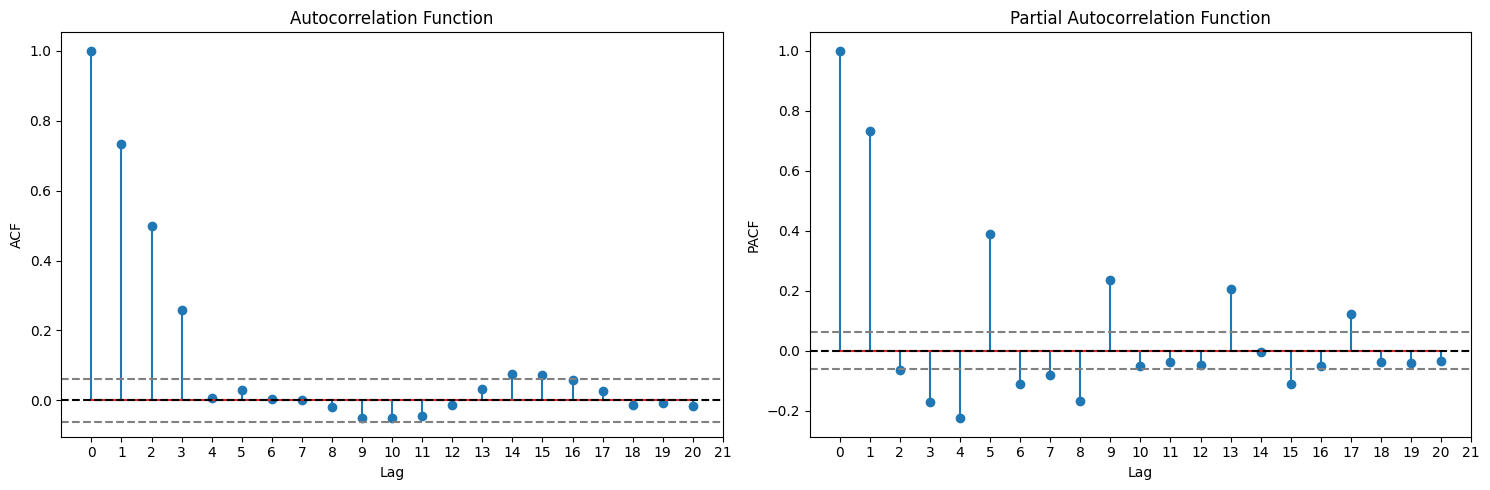

In [99]:
# Tạo sẵn layout 1 hàng, 2 cột
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plotting ACF:
ax[0].stem(lag_acf)
ax[0].axhline(y=0, linestyle='--', color='black')
ax[0].axhline(y=-1.96/np.sqrt(len(ts_diff)), linestyle='--', color='gray')
ax[0].axhline(y=1.96/np.sqrt(len(ts_diff)), linestyle='--', color='gray')
ax[0].set_xticks(range(0, 22, 1))
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')
ax[0].set_title('Autocorrelation Function')

# Plotting PACF:
ax[1].stem(lag_pacf)
ax[1].axhline(y=0, linestyle='--', color='black')
ax[1].axhline(y=-1.96/np.sqrt(len(actuals)), linestyle='--', color='gray')
ax[1].axhline(y=1.96/np.sqrt(len(actuals)), linestyle='--', color='gray')
ax[1].set_xticks(range(0, 22, 1))
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('PACF')
ax[1].set_title('Partial Autocorrelation Function')

plt.tight_layout()
plt.show()


- Chọn được:
    + **q = 3**: cut-off tại lag 3
    + **p = 10**: tới lag 10 thì vào ngưỡng an toàn

#### Training

In [90]:
param_book = (10, 4, 1)
param_custom = (10, 4, 3)
# ARIMA_model = ARIMA(actuals, order = param_book)
ARIMA_model_book = ARIMA(actuals, order = param_book)
ARIMA_model_book = ARIMA_model_book.fit()

ARIMA_model_custom = ARIMA(actuals, order = param_custom)
ARIMA_model_custom = ARIMA_model_custom.fit()

/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/nii/anaconda3/envs/conda_sgu_dm_2026_time-series/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starti

In [91]:
predictions_book = ARIMA_model_book.get_forecast(len(test_data.index))
predictions_df_book = predictions_book.conf_int(alpha = 0.05)
predictions_df_book["Predictions"] = ARIMA_model_book.predict(start = predictions_df_book.index[0], end = predictions_df_book.index[-1])
predictions_df_book.index = test_data.index
predictions_arima_book = predictions_df_book["Predictions"]

predictions_custom = ARIMA_model_custom.get_forecast(len(test_data.index))
predictions_df_custom = predictions_custom.conf_int(alpha = 0.05)
predictions_df_custom["Predictions"] = ARIMA_model_custom.predict(start = predictions_df_custom.index[0], end = predictions_df_custom.index[-1])
predictions_df_custom.index = test_data.index
predictions_arima_custom = predictions_df_custom["Predictions"]


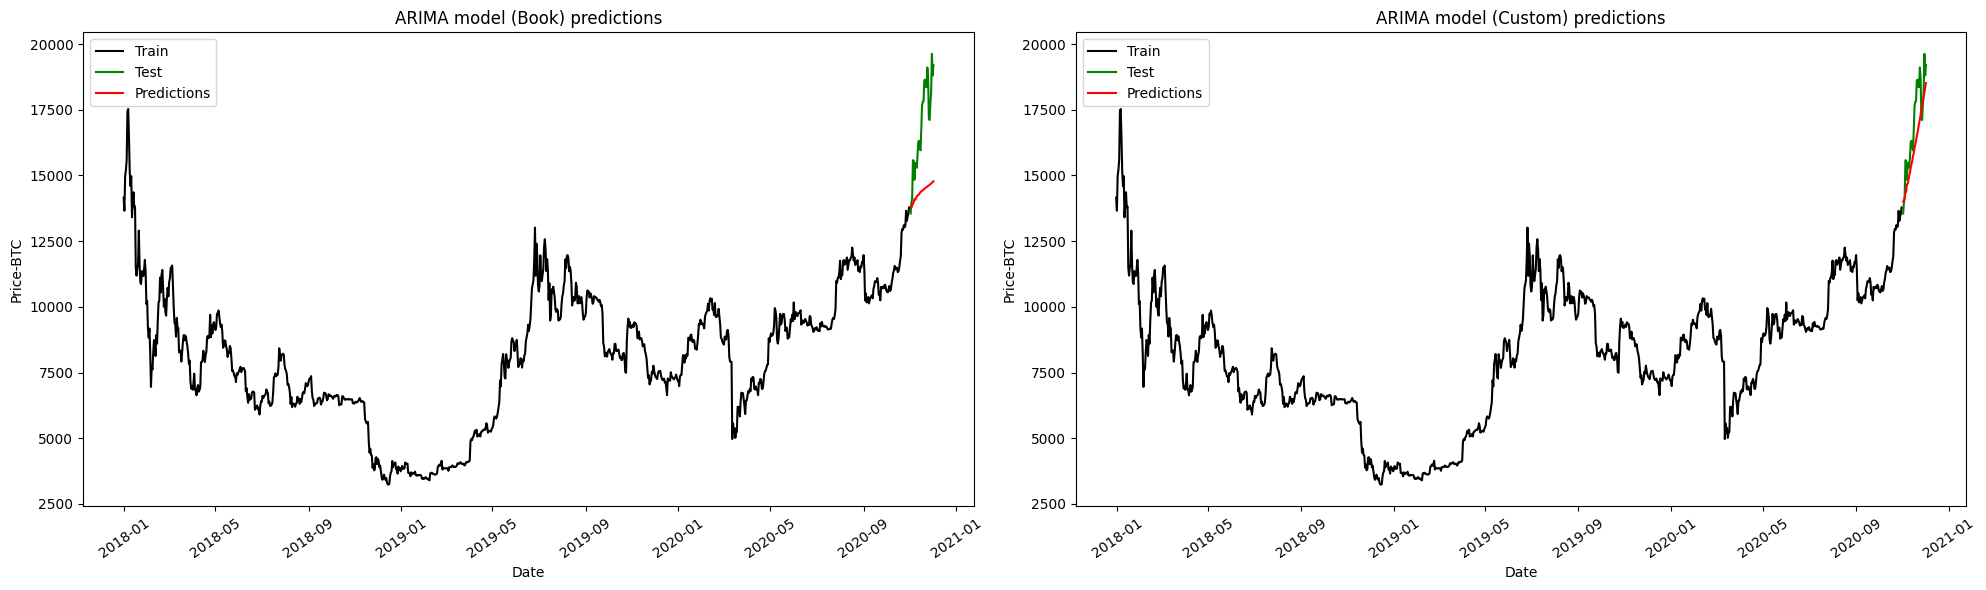

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot Book
axes[0].plot(train_data, color="black", label='Train')
axes[0].plot(test_data, color="green", label='Test')
axes[0].set_ylabel('Price-BTC')
axes[0].set_xlabel('Date')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_title("ARIMA model (Book) predictions")
axes[0].plot(predictions_arima_book, color="red", label='Predictions')
axes[0].legend()

# Plot Custom
axes[1].plot(train_data, color="black", label='Train')
axes[1].plot(test_data, color="green", label='Test')
axes[1].set_ylabel('Price-BTC')
axes[1].set_xlabel('Date')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_title("ARIMA model (Custom) predictions")
axes[1].plot(predictions_arima_custom, color="red", label='Predictions')
axes[1].legend()

plt.tight_layout()
plt.show()


In [93]:
rmse_arima_book = np.sqrt(mean_squared_error(test_data["BTC-USD"].values, predictions_df_book["Predictions"]))
rmse_arima_custom = np.sqrt(mean_squared_error(test_data["BTC-USD"].values, predictions_df_custom["Predictions"]))
print("RMSE_book: ",rmse_arima_book)
print("RMSE_custom: ",rmse_arima_custom)

RMSE_book:  2895.471394620076
RMSE_custom:  1090.5685963608312


## Grid search hyperparameter &rarr; best ARIMA model

In [94]:
def arima_model_evaluate(train_actuals, test_data, order):
    # Model initalize and fit
    ARIMA_model = ARIMA(actuals, order = order)
    ARIMA_model = ARIMA_model.fit()
    # Getting the predictions
    predictions = ARIMA_model.get_forecast(len(test_data.index))
    predictions_df = predictions.conf_int(alpha = 0.05)
    predictions_df["Predictions"] = ARIMA_model.predict(start = predictions_df.index[0], end = predictions_df.index[-1])
    predictions_df.index = test_data.index
    predictions_arima = predictions_df["Predictions"]
    # calculate RMSE score
    rmse_score = np.sqrt(mean_squared_error(test_data["BTC-USD"].values, predictions_df["Predictions"]))
    return rmse_score

In [95]:
def evaluate_models(train_actuals, test_data, list_p_values,
    list_d_values, list_q_values):
    best_rmse, best_config = float("inf"), None
    for p in list_p_values:
        for d in list_d_values:
            for q in list_q_values:
                arima_order = (p,d,q)
                rmse = arima_model_evaluate(train_actuals,test_data, arima_order)
                if rmse < best_rmse:
                    best_rmse, best_config = rmse, arima_order
                print('ARIMA%s RMSE=%.3f' % (arima_order,rmse))
    print('Best Configuration: ARIMA%s , RMSE=%.3f' % (best_config, best_rmse))
    return best_config

In [ ]:
p_values = range(0, 4)
d_values = range(0, 4)
q_values = range(0, 4)
warnings.filterwarnings("ignore")
best_config = evaluate_models(actuals,test_data, p_values,d_values, q_values)

ARIMA(0, 0, 0) RMSE=8973.269
ARIMA(0, 0, 1) RMSE=8927.094
ARIMA(0, 0, 2) RMSE=8895.924
ARIMA(0, 0, 3) RMSE=8861.500
ARIMA(0, 1, 0) RMSE=3527.133
ARIMA(0, 1, 1) RMSE=3537.297
ARIMA(0, 1, 2) RMSE=3519.475
ARIMA(0, 1, 3) RMSE=3514.476
ARIMA(0, 2, 0) RMSE=1112.565
ARIMA(0, 2, 1) RMSE=3455.709
ARIMA(0, 2, 2) RMSE=3317.666
ARIMA(0, 2, 3) RMSE=3337.191
ARIMA(0, 3, 0) RMSE=30160.941
ARIMA(0, 3, 1) RMSE=887.424
ARIMA(0, 3, 2) RMSE=3171.680
ARIMA(0, 3, 3) RMSE=2967.762
ARIMA(1, 0, 0) RMSE=4079.516
ARIMA(1, 0, 1) RMSE=4017.145
ARIMA(1, 0, 2) RMSE=4065.809
ARIMA(1, 0, 3) RMSE=4087.068
ARIMA(1, 1, 0) RMSE=3537.539
ARIMA(1, 1, 1) RMSE=3535.791
ARIMA(1, 1, 2) RMSE=3537.341
ARIMA(1, 1, 3) RMSE=3504.703
ARIMA(1, 2, 0) RMSE=725.218
ARIMA(1, 2, 1) RMSE=3294.487
ARIMA(1, 2, 2) RMSE=3507.106
ARIMA(1, 2, 3) RMSE=3314.431
ARIMA(1, 3, 0) RMSE=12360.360
ARIMA(1, 3, 1) RMSE=727.351
ARIMA(1, 3, 2) RMSE=2969.788
ARIMA(1, 3, 3) RMSE=3014.310
ARIMA(2, 0, 0) RMSE=4014.318
ARIMA(2, 0, 1) RMSE=4020.646
ARIMA(2, 0, 2) 

In [ ]:
ARIMA_model = ARIMA(actuals, order = best_config)
ARIMA_model = ARIMA_model.fit()

In [ ]:
predictions = ARIMA_model.get_forecast(len(test_data.index))
predictions_df = predictions.conf_int(alpha = 0.05)
predictions_df["Predictions"] = ARIMA_model.predict(start =
predictions_df.index[0], end = predictions_df.index[-1])
predictions_df.index = test_data.index
predictions_arima = predictions_df["Predictions"]

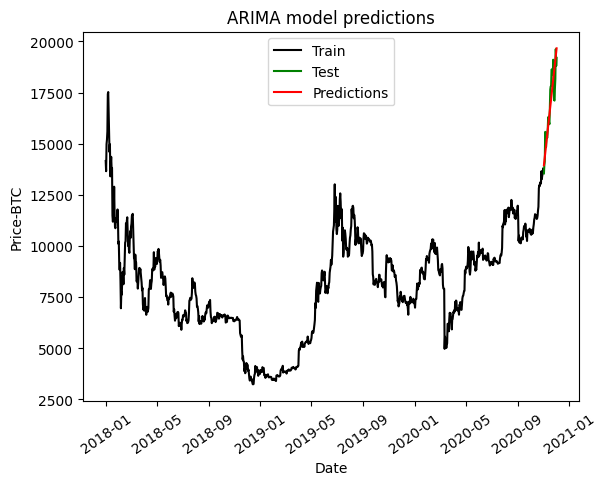

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Book
axes[0].plot(train_data, color="black", label='Train')
axes[0].plot(test_data, color="green", label='Test')
axes[0].set_ylabel('Price-BTC')
axes[0].set_xlabel('Date')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_title("ARIMA model (Book) predictions")
axes[0].plot(predictions_arima_book, color="red", label='Predictions')
axes[0].legend()

# Plot Custom
axes[1].plot(train_data, color="black", label='Train')
axes[1].plot(test_data, color="green", label='Test')
axes[1].set_ylabel('Price-BTC')
axes[1].set_xlabel('Date')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_title("ARIMA model (Custom) predictions")
axes[1].plot(predictions_arima_custom, color="red", label='Predictions')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
rmse_arima = np.sqrt(mean_squared_error(test_data["BTC-USD"].
values, predictions_df["Predictions"]))
print("RMSE: ",rmse_arima)

RMSE:  725.2180143483145


## SARIMA model

### Implement

In [ ]:
SARIMA_model = SARIMAX(actuals, order = (1, 2, 0), seasonal_order=(2,2,2,12))
SARIMA_model = SARIMA_model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.82685D+00    |proj g|=  1.45993D-01

At iterate    5    f=  7.75475D+00    |proj g|=  4.42389D-03

At iterate   10    f=  7.75390D+00    |proj g|=  3.66505D-03

At iterate   15    f=  7.73593D+00    |proj g|=  6.24586D-03

At iterate   20    f=  7.73502D+00    |proj g|=  7.82835D-04

At iterate   25    f=  7.73439D+00    |proj g|=  1.06302D-02

At iterate   30    f=  7.63608D+00    |proj g|=  3.30399D-01

At iterate   35    f=  7.50922D+00    |proj g|=  3.78247D-02

At iterate   40    f=  7.36413D+00    |proj g|=  1.46850D-01

At iterate   45    f=  7.32499D+00    |proj g|=  2.62760D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = nu

In [ ]:
predictions = SARIMA_model.get_forecast(len(test_data.index))
predictions_df = predictions.conf_int(alpha = 0.05)
predictions_df["Predictions"] = SARIMA_model.predict(start =predictions_df.index[0], end = predictions_df.index[-1])
predictions_df.index = test_data.index
predictions_sarima = predictions_df["Predictions"]

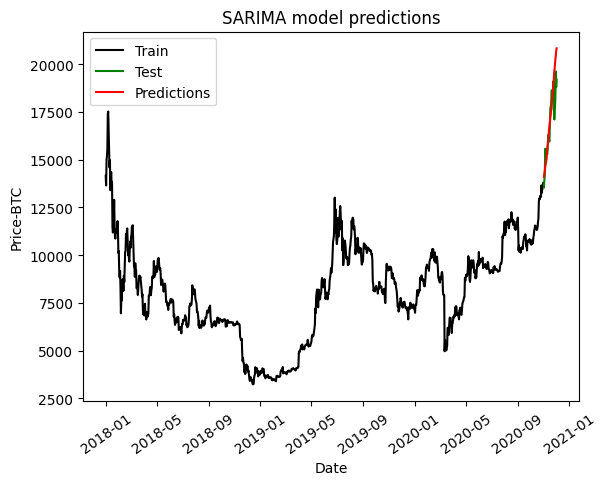

In [ ]:
plt.plot(train_data, color = "black", label = 'Train')
plt.plot(test_data, color = "green", label = 'Test')
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=35)
plt.title("SARIMA model predictions")
plt.plot(predictions_sarima, color="red", label ='Predictions')
plt.legend()
plt.show()

In [ ]:
rmse_sarima = np.sqrt(mean_squared_error(test_data["BTC-USD"].values, predictions_df["Predictions"]))
print("RMSE: ",rmse_sarima)

RMSE:  1046.8473414001319


## SES

In [ ]:
SES_model = SimpleExpSmoothing(actuals)
SES_model = SES_model.fit(smoothing_level=0.8,optimized=False)


In [ ]:
predictions_ses = SES_model.forecast(len(test_data.index))

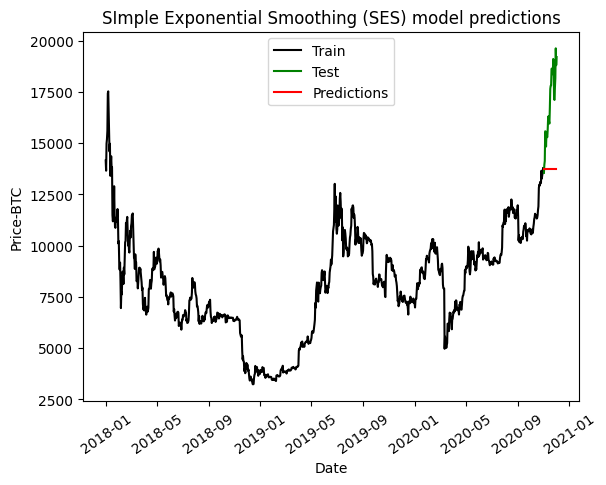

In [ ]:
plt.plot(train_data, color = "black", label = 'Train')
plt.plot(test_data, color = "green", label = 'Test')
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=35)
plt.title("SImple Exponential Smoothing (SES) model predictions")
plt.plot(predictions_ses, color='red', label = 'Predictions')
plt.legend()
plt.show()

In [ ]:
rmse_ses = np.sqrt(mean_squared_error(test_data["BTC-USD"].
values, predictions_ses))
print("RMSE: ",rmse_ses)

RMSE:  3573.2074287577966


## HW model

In [ ]:
HW_model = ExponentialSmoothing(actuals, trend='add')
HW_model = HW_model.fit()

In [ ]:
predictions_hw = HW_model.forecast(len(test_data.index))

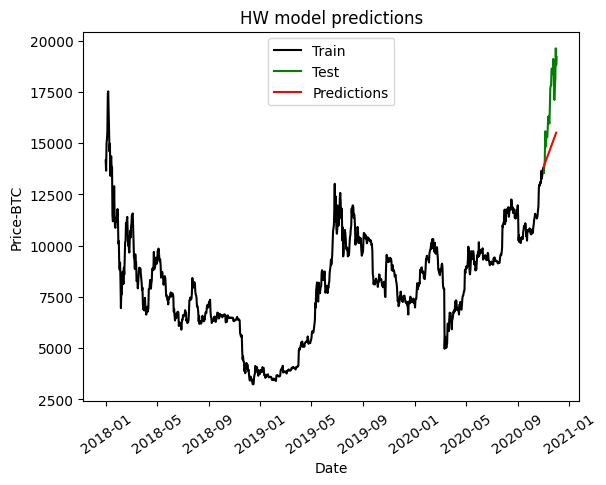

In [ ]:
plt.plot(train_data, color = "black", label = 'Train')
plt.plot(test_data, color = "green", label = 'Test')
plt.ylabel('Price-BTC')
plt.xlabel('Date')
plt.xticks(rotation=35)
plt.title("HW model predictions")
plt.plot(predictions_hw, color='red', label = 'Predictions')
plt.legend()
plt.show()

In [ ]:
rmse_hw = np.sqrt(mean_squared_error(test_data["BTC-USD"].
values, predictions_hw))
print("RMSE: ",rmse_hw)

RMSE:  2538.1012285586617
